# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [11]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 33.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [4]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [5]:
# This will check for duplicate rows
df[df.duplicated()]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
14,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,19,3916,31500
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
24,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
25,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11481,Suzuki,X-90,1998,regular unleaded,95.0,4.0,MANUAL,four wheel drive,2.0,Compact,2dr SUV,26,22,481,2000
11603,Volvo,XC60,2017,regular unleaded,302.0,4.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr SUV,29,20,870,46350
11604,Volvo,XC60,2017,regular unleaded,240.0,4.0,AUTOMATIC,front wheel drive,4.0,Midsize,4dr SUV,30,23,870,40950
11708,Suzuki,XL7,2008,regular unleaded,252.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr SUV,22,15,481,29149


In [7]:
# The following set of cells will help to determine anamolies with the data which I
# will handle on a case by case basis
fig = px.scatter(data_frame=df, x=df["Engine HP"], y=df["Engine Cylinders"], title="Engine Cylinders VS Engine Horsepower")
fig.update_layout(xaxis_title="Engine HP", yaxis_title="Engine Cylinders")

In [5]:
df[df["Engine Cylinders"] == 0].info()

<class 'pandas.DataFrame'>
Index: 56 entries, 539 to 9872
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               56 non-null     str    
 1   Model              56 non-null     str    
 2   Year               56 non-null     int64  
 3   Engine Fuel Type   56 non-null     str    
 4   Engine HP          13 non-null     float64
 5   Engine Cylinders   56 non-null     float64
 6   Transmission Type  56 non-null     str    
 7   Driven_Wheels      56 non-null     str    
 8   Number of Doors    51 non-null     float64
 9   Vehicle Size       56 non-null     str    
 10  Vehicle Style      56 non-null     str    
 11  highway MPG        56 non-null     int64  
 12  city mpg           56 non-null     int64  
 13  Popularity         56 non-null     int64  
 14  MSRP               56 non-null     int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 7.0 KB


In [8]:
fig = px.scatter(data_frame=df, x=df["Engine HP"], y=df["MSRP"], title="Engine Cylinders VS MSRP")
fig.update_layout(xaxis_title="Engine HP", yaxis_title="MSRP")

In [9]:
df[df["MSRP"] > 550000].info()

<class 'pandas.DataFrame'>
Index: 7 entries, 4024 to 11364
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               7 non-null      str    
 1   Model              7 non-null      str    
 2   Year               7 non-null      int64  
 3   Engine Fuel Type   7 non-null      str    
 4   Engine HP          7 non-null      float64
 5   Engine Cylinders   7 non-null      float64
 6   Transmission Type  7 non-null      str    
 7   Driven_Wheels      7 non-null      str    
 8   Number of Doors    7 non-null      float64
 9   Vehicle Size       7 non-null      str    
 10  Vehicle Style      7 non-null      str    
 11  highway MPG        7 non-null      int64  
 12  city mpg           7 non-null      int64  
 13  Popularity         7 non-null      int64  
 14  MSRP               7 non-null      int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 896.0 bytes


In [10]:
df.isna().sum()

Make                  0
Model                 0
Year                  0
Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Number of Doors       6
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64

In [11]:
df[df["Engine Fuel Type"].isna()]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11321,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,17,481,17199
11322,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,17,481,20199
11323,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,17,481,18499


In [12]:
df[(df["Make"] == "Suzuki") & (df["Model"] == "Verona") & (df["Year"] == 2004)]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11321,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,17,481,17199
11322,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,17,481,20199
11323,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,17,481,18499


In [13]:
df["Engine Fuel Type"].value_counts(dropna=False)

Engine Fuel Type
regular unleaded                                7172
premium unleaded (required)                     2009
premium unleaded (recommended)                  1523
flex-fuel (unleaded/E85)                         899
diesel                                           154
electric                                          66
flex-fuel (premium unleaded required/E85)         54
flex-fuel (premium unleaded recommended/E85)      26
flex-fuel (unleaded/natural gas)                   6
NaN                                                3
natural gas                                        2
Name: count, dtype: int64

In [14]:
for column in df:
    print(f"{column}: {df[column].dtype}")
print("Length of Number of Doors Column: ", len(df["Number of Doors"]))

Make: str
Model: str
Year: int64
Engine Fuel Type: str
Engine HP: float64
Engine Cylinders: float64
Transmission Type: str
Driven_Wheels: str
Number of Doors: float64
Vehicle Size: str
Vehicle Style: str
highway MPG: int64
city mpg: int64
Popularity: int64
MSRP: int64
Length of Number of Doors Column:  11914


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 |Duplicate rows are present througout the DataFrame. |I checked for rows where df.duplicated() evaluates to true. |720 | I chose to keep these duplicated rows.| This is because they are still useful pieces of data we can use when we're computing the mean that still represent different cars, even if they have the same properties. |
| 2 |NaN rows were present in the Engine Fuel Type, Engine HP, Engine Cylinders, and Number of Doors columns. |I discovered this by taking the sum of NaN rows for each column in the DataFrame. |108 | I chose to drop these rows. | I did this because I didn't find enough evidence to create assumptions for what these values should be and guessing/estimating numbers may skew the data in a way that may create misleading conclusions.|
| 3 | There are outliers present in each column of the DataFrame represnting abnormal maximums that skew the data.|I discovered this by using Plotly Express's scatter plot on some columns such as Engine Horsepower VS MSRP, which helped me to notice these outliers (such as abonrmal prices in the millions, which is more representative of luxury vehicles which aren't commonly purchased). | 7| I chose to flag these rows.| This is because these rows still represent valid pricing and vehicle data, although they should be taken special care of during analysis to ensure that they don't skew the data and create misleading results.|
| 4 | There is invalid data present in the Engine Cylinders column.| I discovered this by using Plotly Express's scatter plot which revealed that Engines which had 0 cylinders have a certain amount of horse power (even though they shouldn't have any if that's really true).| 56| I chose to drop these rows.|This is because there isn't enough evidence in the data itself that suggests a default value to use for the amount of cylinders that correponds to the horsepower amounts displayed in the graph of which I made this discovery. |
| 5 |The data type of the Number of Doors column is incorrect. It should be an int instead of a float, since you can't have a fraction of a car door. | I discovered this by printing out the dtype of each column through a for loop, finding that the dtype of this column was float when it should be int.| 11,914|I chose to keep these rows. | I can convert the dtype of these to the correct one after addressing the issues with the NaN rows, since this issue may actually stem from that.|

In [15]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names
clean = clean.dropna(axis=0, subset=['engine_fuel_type', 'engine_cylinders', 'number_of_doors']) # fixes problems 2
clean["is_outlier"] = np.where(clean["msrp"] > 550000, 1, 0) # fixes problem 3
clean = clean[~(clean["engine_cylinders"] == 0)] # fixes problem 4
clean["number_of_doors"] = clean["number_of_doors"].astype(int) # fixes problem 5

In [16]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11824, 16)
engine_hp    25
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean (without log transformation): 40561.63
Median (without log transformation): 29980.0
Mean (with log transformation): 4.39
Median (with log transformation): 4.48
Share of cars above the mean (without log transformation): 27.46%
Share of cars above the mean (with log transformation): 65.44%
Typical price of a car: $24547.09


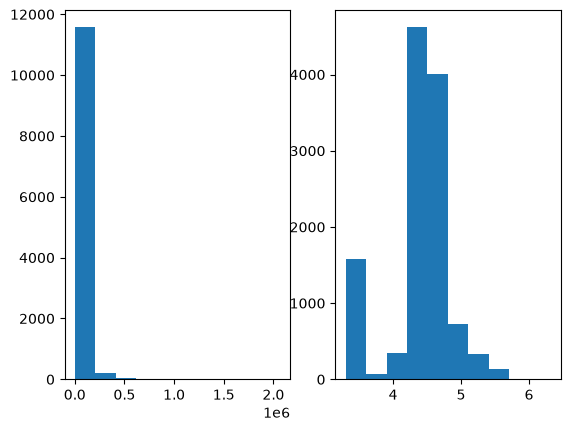

In [17]:
# a) mean and median
msrp = clean["msrp"]
mean = round(msrp.mean(), 2)
median = round(msrp.median(), 2)
mean2 = round(np.log10(msrp).mean(), 2)
median2 = round(np.log10(msrp).median(), 2)
print(f"Mean (without log transformation): {mean}")
print(f"Median (without log transformation): {median}")
print(f"Mean (with log transformation): {mean2}")
print(f"Median (with log transformation): {median2}")
# b) two histograms side by side (plt.subplots(1, 2))
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(msrp)
ax2.hist(np.log10(msrp))
fig.show()
# c) share of cars above the mean
clean["msrp_with_log"] = np.log10(clean["msrp"])
msrp_with_log = clean["msrp_with_log"]
above_mean_no_log = len(clean[msrp > mean])
above_mean_with_log = len(clean[msrp_with_log > mean2])
total_car_share = len(msrp)
above_mean_share_no_log = round((above_mean_no_log/total_car_share) * 100, 2)
above_mean_share_with_log = round((above_mean_with_log/total_car_share) * 100, 2)

print(f"Share of cars above the mean (without log transformation): {above_mean_share_no_log}%")
print(f"Share of cars above the mean (with log transformation): {above_mean_share_with_log}%")

typical_price = round(pow(10, mean2), 2)
print(f"Typical price of a car: ${typical_price}") 

**Answer: The mean is bigger than the median without a log transformation applied, and this is because the extreme values end up skewing the data, making the mean much bigger than the median. When a log transformation is applied, the median ends up being larger than the mean because the log transformation compresses the extreme values which not only shortens the gap between the two but also better reflects the true nature of the data. Without a log transformation, the histogram looks very consolidated to the left whereas with a log transformation, the data is much more spread out with the center being the point of emphasis. Without a log transformation, I found that the number of cars above the mean was approximately 27.46%, while with a log transformation applied, that percentage becomes approximately 65.44%. The number that belongs to the homepage is $24,547.09, or if the manager wishes to have this value rounded further, $24,548. This is because this is based on the mean after the log transformation is applied, in which the mean more accurately represents the average and the application of the log function takes extreme values into account better.**

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [18]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
clean_filtered_by_year = clean[clean["year"] == 2017]
means = list(round(clean_filtered_by_year.groupby("vehicle_size")["highway_mpg"].mean(), 2))
stds = list(round(clean_filtered_by_year.groupby("vehicle_size")["highway_mpg"].std(), 2))
compact_mean = means[0]
midsize_mean = means[1]
large_mean = means[2]
compact_std = stds[0]
midsize_std = stds[1]
large_std = stds[2]
print(f"Compact Mean: {compact_mean}")
print(f"Midsize Mean: {midsize_mean}")
print(f"Large Mean: {large_mean}")
print(f"Compact Standard Deviation: {compact_std}")
print(f"Midsize Standard Deviation: {midsize_std}")
print(f"Large Standard Deviation: {large_std}")
# b) z = (value - class mean) / class std
compact_z_score = round((42 - compact_mean) / compact_std, 2)
large_z_score = round((34 - large_mean) / large_std, 2)
print(f"Z-score for the 2017 Compact Honda Civic: {compact_z_score}")
print(f"Z-score for the 2017 Large Volvo S90: {large_z_score}")

Compact Mean: 30.75
Midsize Mean: 22.94
Large Mean: 30.0
Compact Standard Deviation: 6.07
Midsize Standard Deviation: 3.5
Large Standard Deviation: 13.76
Z-score for the 2017 Compact Honda Civic: 1.85
Z-score for the 2017 Large Volvo S90: 0.29


**Answer: The 2017 Compact Honda Civic is more fuel-efficient for its class, given that it is 1.85 (nearly 2) standard deviations above the fuel-efficiency of the average Compact car while the 2017 Large Volvo S90 is only 0.29 standard deviations above the fuel-efficiency of the average Large car, placing it slightly above average for its class.**

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

The 2.5th percentile for 2017: 35850.0
The 97.5th percentile for 2017: 37660.0
The 2.5th percentile for the first 50 cars in 2017: 43950.0
The 97.5th percentile for the first 50 cars in 2017: 50300.0


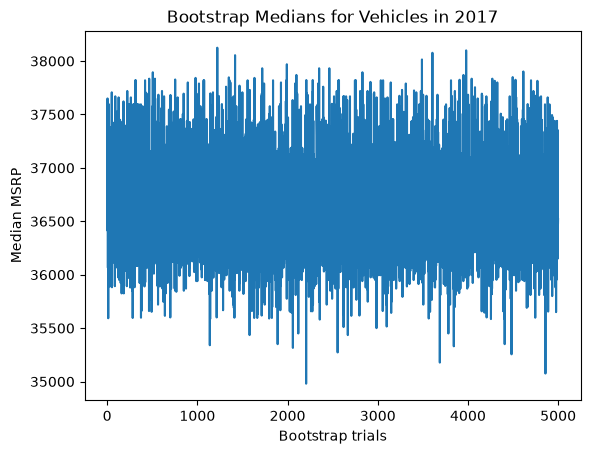

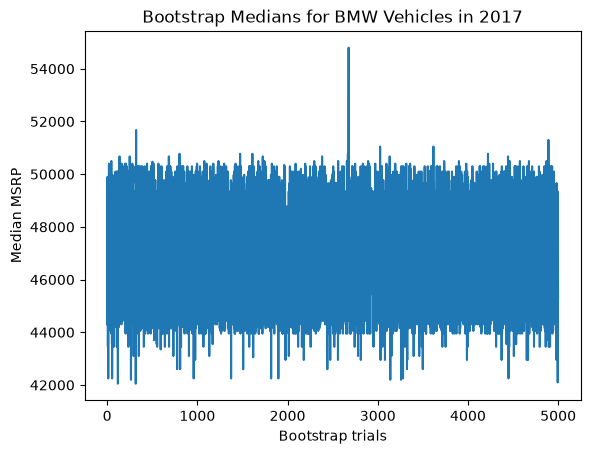

In [19]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    median_list = []
    for n in range(0, n_boot):
        rng = np.random.default_rng()
        current_batch = rng.choice(values, size=len(values), replace=True)
        batch_median = np.median(current_batch)
        median_list.append(batch_median)
    return np.array(median_list)

# a, b)
clean_2017 = clean[clean["year"] == 2017]
median_2017_msrp = round(np.log10(clean_2017["msrp"]).median(), 2)
bootstrap_1 = bootstrap_median(clean_2017["msrp"])
plt.figure()
plt.plot(bootstrap_1)
plt.title("Bootstrap Medians for Vehicles in 2017")
plt.xlabel("Bootstrap trials")
plt.ylabel("Median MSRP")
interval = np.percentile(bootstrap_1, [2.5, 97.5])
print(f"The 2.5th percentile for 2017: {interval[0]}")
print(f"The 97.5th percentile for 2017: {interval[1]}")
# c)
clean_2017_focused = clean_2017[clean_2017["make"] == "BMW"].head(40)
median_msrp_focused = round(np.log10(clean_2017_focused["msrp"]).median(), 2)
bootstrap_2 = bootstrap_median(clean_2017_focused["msrp"])
plt.figure()
plt.plot(bootstrap_2)
plt.title("Bootstrap Medians for BMW Vehicles in 2017")
plt.xlabel("Bootstrap trials")
plt.ylabel("Median MSRP")
interval_2 = np.percentile(bootstrap_2, [2.5, 97.5])
print(f"The 2.5th percentile for the first 50 cars in 2017: {interval_2[0]}")
print(f"The 97.5th percentile for the first 50 cars in 2017: {interval_2[1]}")

**Answer: The interval is more narrow when doing all cars from 2017 focused on the BMW make as opposed to doing only the first 50 cars from 2017 that have the BMW make, and this is because there are more samples to take medians from, so the spread is going to be much more concentrated. The change in part b tells us that we are 95% confident that the true median price lies in between $35889.81 and $37660.**

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Sample size of cars: 526
TtestResult(statistic=np.float64(-23.057052813434918), pvalue=np.float64(1.0), df=np.int64(525))
TtestResult(statistic=np.float64(-6.913551599413894), pvalue=np.float64(0.9999999995705333), df=np.int64(84))


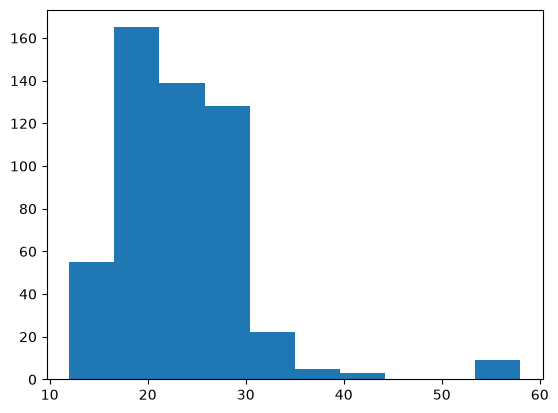

In [20]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
# Assumption: By "mpg", we mean city mpg
compacts_2017 = clean[(clean["vehicle_size"] == "Compact") & (clean["year"] == 2017)]
compacts_2017_mean = compacts_2017["city_mpg"].mean()
plt.hist(compacts_2017["city_mpg"])
print(f"Sample size of cars: {len(compacts_2017)}")
# c) one-sample t-test vs 30
a = 0.05
print(stats.ttest_1samp(compacts_2017["city_mpg"], 30, alternative="greater"))
# d) rows per make+model, then one row per model and retest
rows_per_make_model = list(compacts_2017.groupby(["make", "model"])["city_mpg"].mean())
print(stats.ttest_1samp(rows_per_make_model, 30, alternative="greater"))

**Answer:H₀ in this case would be "our 2017 compacts do not average over 30 MPG", while Hₐ is "our 2017 compacts do average over 30 MPG". This is one-sided, because we only care if the compacts average over 30 MPG, not if it averages under, thus we only care about one direction. This distribution looks right-skewed given that most of the data is concentrated towards the left of the graph, and a t-test is reasonable here because we have a sufficient sample size, which will make the sampling distrubtion approximately normal in spite of the skew. As for the result of the t-test, because the p-value is 1.0, we have no evidence to reject the null hypothesis that "our 2017 compacts do not average over 30 mpg". When re-running the t-test after making adjustments, the degrees of freedom (df) went down to 84, the t-statistic increased to approxiamtely -6 and the p-value went slightly down but not by much, supporting the observation from earlier about whether we can reject the null hypothesis. The version that I trust more is the second t-test, and this is because with the first t-test every row was treated as a seperate observation which can artifically inflate the sample size, while the sample size is much more condensed in the second t-test because we took into account the fact that the same cars are not individual observations.**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [21]:
# a) compare median MSRP by transmission type
transmission_type_auto = clean[clean["transmission_type"] == "AUTOMATIC"]
transmission_type_manual = clean[clean["transmission_type"] == "MANUAL"]
transmission_type_auto_msrp_median = round(transmission_type_auto["msrp"].median(), 2)
transmission_type_manual_msrp_median = round(transmission_type_manual["msrp"].median(), 2)
print(f"Median MSRP for Automatic Transmission: {transmission_type_auto_msrp_median}")
print(f"Median MSRP for Manual Transmission: {transmission_type_manual_msrp_median}")
# b) compare year by transmission type
transmission_type_auto_year_min = transmission_type_auto["year"].min()
transmission_type_auto_year_max = transmission_type_auto["year"].max()
transmission_type_manual_year_min = transmission_type_manual["year"].min()
transmission_type_manual_year_max = transmission_type_manual["year"].max()
print(f"Years of Automatic Transmission: {transmission_type_auto_year_min}-{transmission_type_auto_year_max}")
print(f"Years of Manual Transmission: {transmission_type_manual_year_min}-{transmission_type_manual_year_max}")
# c) compare 2015-2017 medians overall and within each vehicle_size
transmission_type_auto_by_year = clean[(clean["transmission_type"] == "AUTOMATIC") & (2015 >= clean["year"]) & (clean["year"] <= 2017)]
transmission_type_manual_by_year = clean[(clean["transmission_type"] == "MANUAL") & (2015 >= clean["year"]) & (clean["year"] <= 2017)]
transmission_type_auto_msrp_median_by_year = list(round(transmission_type_auto_by_year.groupby("vehicle_size")["msrp"].median(), 2))
transmission_type_manual_msrp_median_by_year = list(round(transmission_type_manual_by_year.groupby("vehicle_size")["msrp"].median(), 2))
print(f"Median MSRP for Automatic Transmission in 2015-2017 for Compact Vehicles: {transmission_type_auto_msrp_median_by_year[0]}")
print(f"Median MSRP for Automatic Transmission in 2015-2017 for Midsize Vehicles: {transmission_type_auto_msrp_median_by_year[1]}")
print(f"Median MSRP for Automatic Transmission in 2015-2017 for Large Vehicles: {transmission_type_auto_msrp_median_by_year[2]}")
print(f"Median MSRP for Manual Transmission in 2015-2017 for Compact Vehicles: {transmission_type_manual_msrp_median_by_year[0]}")
print(f"Median MSRP for Manual Transmission in 2015-2017 for Midsize Vehicles: {transmission_type_manual_msrp_median_by_year[1]}")
print(f"Median MSRP for Manual Transmission in 2015-2017 for Large Vehicles: {transmission_type_manual_msrp_median_by_year[2]}")
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
transmission_type_auto_by_year_compact = clean[(clean["transmission_type"] == "AUTOMATIC") & (clean["vehicle_size"] == "Compact") & (clean["year"] >= 2015) & (clean["year"] <= 2017)]
transmission_type_manual_by_year_compact = clean[(clean["transmission_type"] == "MANUAL") & (clean["vehicle_size"] == "Compact") & (clean["year"] >= 2015) & (clean["year"] <= 2017)]
print(stats.mannwhitneyu(transmission_type_auto_by_year_compact["msrp"], transmission_type_manual_by_year_compact["msrp"]))

Median MSRP for Automatic Transmission: 32580.0
Median MSRP for Manual Transmission: 18697.5
Years of Automatic Transmission: 1990-2017
Years of Manual Transmission: 1990-2017
Median MSRP for Automatic Transmission in 2015-2017 for Compact Vehicles: 23870.0
Median MSRP for Automatic Transmission in 2015-2017 for Midsize Vehicles: 37030.0
Median MSRP for Automatic Transmission in 2015-2017 for Large Vehicles: 31335.0
Median MSRP for Manual Transmission in 2015-2017 for Compact Vehicles: 16210.0
Median MSRP for Manual Transmission in 2015-2017 for Midsize Vehicles: 2922.0
Median MSRP for Manual Transmission in 2015-2017 for Large Vehicles: 22274.0
MannwhitneyuResult(statistic=np.float64(346203.0), pvalue=np.float64(0.0941621665794619))


**Answer:The years of the Manual and Automatic cars line up perfectly between 1990-2017, but the problem with this is that Manual car prices are skewed towards older years while Automatics are skewed towards more recent years, so you would be comparing their MSRP across the entire timeframe, which isn't a fair comparison. Therefore, it's better to select from both Manual and Automatic prices from a more recent timeframe such as 2015-2017. The p-value medians suggest that the manuals are cheaper across all vehicle types, because the p-value is greater than 0.05 (the standard significance level), it's not possible to reject the null hypothesis. The message I would send to the sales rep is "There is no signficant evidence to back up that statement."**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [31]:
# a) Welch t-test, 4-door vs 2-door
clean_2_door = clean[clean["number_of_doors"] == 2]
clean_4_door = clean[clean["number_of_doors"] == 4]
clean_2_door_mpg = clean_2_door["highway_mpg"]
clean_4_door_mpg = clean_4_door["highway_mpg"]
clean_2_door_mpg_mean = clean_2_door["highway_mpg"].mean()
clean_4_door_mpg_mean = clean_4_door["highway_mpg"].mean()
difference = clean_4_door_mpg_mean - clean_2_door_mpg_mean
print(f"Difference between the means of 2-door car MPG and 4-door car MPG: {difference}")
print(stats.ttest_ind(clean_2_door_mpg, clean_4_door_mpg, equal_var=False))
# b) yearly gas cost = miles * price_per_gallon / mpg
yearly_gas_cost_2_door = (12000 * 3.50) / clean_2_door_mpg_mean
yearly_gas_cost_4_door = (12000 * 3.50) / clean_4_door_mpg_mean
difference_to_dollars = round(yearly_gas_cost_4_door - yearly_gas_cost_2_door, 2)
print(f"Savings from the average 4-door driver: ${difference_to_dollars}")
# c) simulation
n_sims, hits = 1000, 0
rng = np.random.default_rng()
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    two_door_sample_groups = rng.choice(clean_2_door_mpg, 30, replace=False)
    four_door_sample_groups = rng.choice(clean_4_door_mpg, 30, replace=False)
    test_result = stats.ttest_ind(two_door_sample_groups, four_door_sample_groups, equal_var=False)
    if test_result.pvalue < 0.05:
        hits += 1
test_result_percentage = hits / n_sims
print(f"Fractions of significant Welch t-tests given only 30 cars per group: {test_result_percentage}")

Difference between the means of 2-door car MPG and 4-door car MPG: 1.6607936596122137
TtestResult(statistic=np.float64(-12.552325613990579), pvalue=np.float64(9.547379449914774e-36), df=np.float64(6835.611299243139))
Savings from the average 4-door driver: $-102.41
Fractions of significant Welch t-tests given only 30 cars per group: 0.156


**Answer: I would not put that 4-door cars are significantly more fuel-efficient in an ad, as that would be misleading. Even though the Welch t-test reported statistical significance when taking the entire dataset into account, the difference between the mean MPG of 4-door cars and 2-door cars is minimal, and when the scope of the tests is shrunk down to just 30 cars per group only about 15% of the tests came back as significant. What I would say instead is that there some minimal/negligible amounts of savings in fuel for 4-door cars.**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:There is no significant evidence to support that manual cars cost less, because with a p-value of approximately 0.094 (which is greater than the standard statistical significance level of 0.05, where "statistically significant" in this context means how likely manual cars costing less than automatic cars are to happen by random chance) after performing a Mann-Whitney U test, the claim that they cost less would be misleading. One other finding here that matters for pricing is that vehicle prices are right-skewed. This means that more expensive luxury vehicles can artificially inflate the mean for the average car, which can cause cars to be priced incorrectly, so this needs to be taken into account when pricing vehicles by applying a log transformation to the MSRP data. One limitation of this data that a manager should know about is that the pricing data may not account for dealership markups, regional pricing, etc. which can affect the accuracy of mean and median price calculations.**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2